In [4]:
import pickle

pkl_path = r"C:\Users\eric0\Desktop\ML\eric_env\project_1\data\RML2016.10a_dict.pkl"

with open(pkl_path, 'rb') as f:
  data = pickle.load(f, encoding='latin1')

print(type(data))

<class 'dict'>


In [5]:
print(len(data))
print(list(data.keys())[:5])

key = list(data.keys())[0]
print("example key:", key)
print("shape:", data[key].shape)

220
[('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8)]
example key: ('QPSK', 2)
shape: (1000, 2, 128)


In [15]:
key_list = list(data.keys())
print(key_list)

print(data[key_list[0]].shape)

temp_signal = data[key_list[0]][0]
temp_signal_I = temp_signal[0, :]
print(temp_signal_I)

[('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8), ('AM-SSB', 12), ('8PSK', 8), ('8PSK', 12), ('QAM64', -6), ('QAM16', 2), ('QAM16', -20), ('PAM4', -6), ('WBFM', -18), ('AM-DSB', 16), ('CPFSK', 10), ('WBFM', 6), ('BPSK', 4), ('BPSK', -2), ('QPSK', -20), ('CPFSK', -8), ('AM-SSB', 6), ('QAM64', -20), ('QAM16', 12), ('GFSK', -20), ('AM-SSB', -12), ('CPFSK', 0), ('AM-DSB', 6), ('BPSK', -16), ('QPSK', -6), ('8PSK', -12), ('CPFSK', -18), ('BPSK', -10), ('QPSK', 8), ('PAM4', 14), ('AM-DSB', -10), ('GFSK', 12), ('QAM64', 2), ('WBFM', -4), ('AM-SSB', -18), ('QAM64', -4), ('GFSK', -4), ('AM-DSB', 8), ('PAM4', -16), ('QPSK', -16), ('BPSK', 16), ('8PSK', -8), ('CPFSK', 16), ('WBFM', 0), ('QPSK', 6), ('BPSK', 14), ('AM-DSB', -8), ('GFSK', -10), ('CPFSK', -2), ('AM-SSB', 8), ('GFSK', 18), ('QAM16', 6), ('QAM16', -16), ('QAM64', 18), ('AM-SSB', -2), ('CPFSK', 6), ('BPSK', 0), ('BPSK', -6), ('8PSK', -14), ('CPFSK', -12), ('AM-SSB', 2), ('WBFM', 10), ('AM-DSB', -12), ('PAM4', 4), ('G

(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 128)
(1000, 2, 

keys: 220 total samples (approx): 220000
example keys (mod, snr): [('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8), ('AM-SSB', 12)]
Selected key: ('QPSK', 2)
arr shape: (1000, 2, 128)


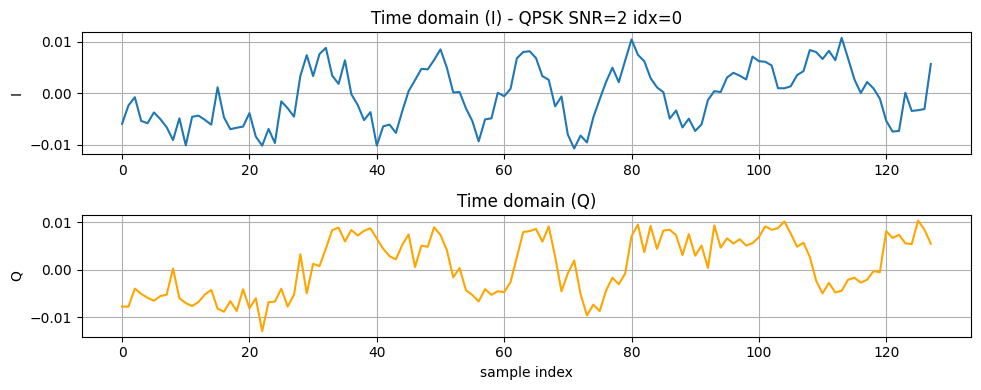

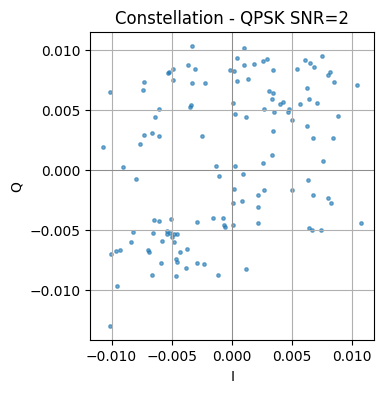

C:\Users\eric0\AppData\Local\Temp\ipykernel_12300\3435852049.py:67: UserWarning: Input data is complex, switching to return_onesided=False
  f, tt, Sxx = signal.spectrogram(I + 1j*Q, fs=fs, nperseg=64, noverlap=48, window='hann')


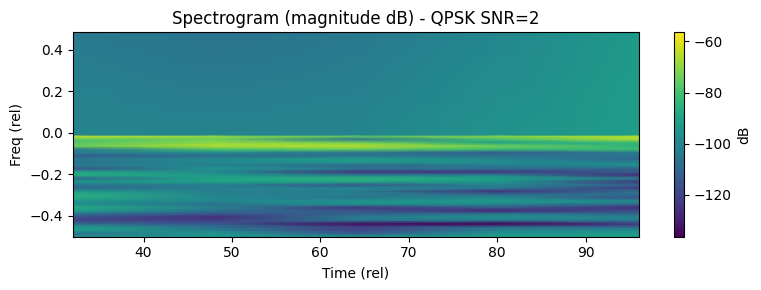

In [6]:
# check_and_plot_rml.py
import pickle
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal    # 用來做 spectrogram（若沒裝可以先 pip install scipy）

pkl_path = r"C:\Users\eric0\Desktop\ML\eric_env\project_1\data\RML2016.10a_dict.pkl"

# 1) 載入 pickle（注意 Python2 pickle -> encoding='latin1'）
with open(pkl_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

# 2) 總樣本數檢查
total_samples = sum(v.shape[0] for v in data.values())
print("keys:", len(data), "total samples (approx):", total_samples)

# 3) 看前幾個 key（modulation, snr）
keys = list(data.keys())
print("example keys (mod, snr):", keys[:6])

# 4) 選一筆 sample：可以隨機或指定
# 例如選第一個 key，第一筆 sample
key = keys[0]               # 或指定: ('QPSK', 10)
modname, snr = key
print("Selected key:", key)
arr = data[key]             # shape (N_per_key, 2, L)
print("arr shape:", arr.shape)

idx = 0                     # 想看第 idx 筆（0..N-1）
sample = arr[idx]           # shape (2, L)
I = sample[0, :]
Q = sample[1, :]
L = I.size
t = np.arange(L)            # index as "time"

# 5) 畫時域 I/Q（上下兩張）
plt.figure(figsize=(10,4))
plt.subplot(2,1,1)
plt.plot(t, I, label='I')
plt.title(f"Time domain (I) - {modname} SNR={snr} idx={idx}")
plt.ylabel('I')
plt.grid(True)
plt.subplot(2,1,2)
plt.plot(t, Q, label='Q', color='orange')
plt.title(f"Time domain (Q)")
plt.ylabel('Q')
plt.xlabel('sample index')
plt.grid(True)
plt.tight_layout()
plt.show()

# 6) 畫 constellation（I vs Q scatter）
plt.figure(figsize=(4,4))
plt.scatter(I, Q, s=6, alpha=0.6)
plt.xlabel('I')
plt.ylabel('Q')
plt.title(f"Constellation - {modname} SNR={snr}")
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.gca().set_aspect('equal', 'box')
plt.grid(True)
plt.show()

# 7) 畫 spectrogram（簡用 scipy.signal.spectrogram）
# 如果你想更像論文常見的 spectrogram，可調 nperseg, noverlap, window
fs = 1.0  # sampling rate relative units; 調成真實 sr (例如 20e6) 可得到實頻率軸
f, tt, Sxx = signal.spectrogram(I + 1j*Q, fs=fs, nperseg=64, noverlap=48, window='hann')
plt.figure(figsize=(8,3))
plt.pcolormesh(tt, f, 20*np.log10(np.abs(Sxx)+1e-12), shading='gouraud')
plt.ylabel('Freq (rel)')
plt.xlabel('Time (rel)')
plt.title(f"Spectrogram (magnitude dB) - {modname} SNR={snr}")
plt.colorbar(label='dB')
plt.tight_layout()
plt.show()